# FLANN Models on Food Waste Time Series

Implements and compares:
- Trigonometric FLANN (TFLANN)
- Chebyshev FLANN (CFLANN)
- Legendre FLANN (LFLANN)

Sliding window: use 2 consecutive samples to predict the 3rd.


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path


In [27]:
# Load dataset (single column, chronological)
file_path = Path('42_Point_Interpolated_Food_Waste_Dataset.xlsx')

df = pd.read_excel(file_path)

# If multiple columns, take the first numeric column
if df.shape[1] > 1:
    series = df.select_dtypes(include=[np.number]).iloc[:, 0].to_numpy()
else:
    series = df.iloc[:, 0].to_numpy()

series = series.astype(float)
print('Total samples:', len(series))
print('First 5:', series[:5])


Total samples: 42
First 5: [2018. 2018. 2018. 2018. 2018.]


In [28]:
# Build supervised dataset using sliding window
# X = [x(t-2), x(t-1)], y = x(t)

def build_supervised(series):
    X, y = [], []
    for i in range(2, len(series)):
        X.append([series[i-2], series[i-1]])
        y.append(series[i])
    return np.array(X, dtype=float), np.array(y, dtype=float)

X, y = build_supervised(series)
print('Supervised X shape:', X.shape, 'y shape:', y.shape)


Supervised X shape: (40, 2) y shape: (40,)


In [29]:
# Train/test split (chronological, 70/30)

n_total = len(y)
train_size = int(np.floor(0.7 * n_total))

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print('Train size:', len(y_train), 'Test size:', len(y_test))


Train size: 28 Test size: 12


In [30]:
# Normalization (fit on train, apply to train/test)

class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None
    
    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self
    
    def transform(self, X):
        return (X - self.mean_) / self.std_
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)

scaler = StandardScaler()
X_train_n = scaler.fit_transform(X_train)
X_test_n = scaler.transform(X_test)


In [31]:
# Basis expansions

# Note: For Chebyshev and Legendre, inputs should be within [-1, 1].
# We will clip the normalized inputs to that range for numerical stability.

def tflann_expand(X, order=3):
    # X shape: (n, 2)
    feats = [np.ones((X.shape[0], 1))]
    for k in range(1, order + 1):
        feats.append(np.sin(k * X))
        feats.append(np.cos(k * X))
    return np.concatenate(feats, axis=1)


def chebyshev_expand(X, order=3):
    Xc = np.clip(X, -1.0, 1.0)
    n, d = Xc.shape
    feats = [np.ones((n, 1))]
    # T0 = 1, T1 = x
    T0 = np.ones_like(Xc)
    if order >= 1:
        T1 = Xc.copy()
        feats.append(T1)
    else:
        T1 = None
    for k in range(2, order + 1):
        Tk = 2 * Xc * T1 - T0
        feats.append(Tk)
        T0, T1 = T1, Tk
    return np.concatenate(feats, axis=1)


def legendre_expand(X, order=3):
    Xc = np.clip(X, -1.0, 1.0)
    n, d = Xc.shape
    feats = [np.ones((n, 1))]
    # P0 = 1, P1 = x
    P0 = np.ones_like(Xc)
    if order >= 1:
        P1 = Xc.copy()
        feats.append(P1)
    else:
        P1 = None
    for k in range(2, order + 1):
        Pk = ((2 * k - 1) * Xc * P1 - (k - 1) * P0) / k
        feats.append(Pk)
        P0, P1 = P1, Pk
    return np.concatenate(feats, axis=1)


In [32]:
# Linear model training (pseudo-inverse / least squares)

def train_pinv(Phi, y):
    # Closed-form solution: w = (Phi^T Phi)^-1 Phi^T y
    # Use np.linalg.pinv for stability
    w = np.linalg.pinv(Phi) @ y
    return w


def predict(Phi, w):
    return Phi @ w


In [33]:
# Gradient descent training (for loss curves)

def train_gd(Phi, y, lr=0.01, epochs=50):
    n, m = Phi.shape
    w = np.zeros(m, dtype=float)
    losses = []
    for _ in range(epochs):
        y_pred = Phi @ w
        err = y_pred - y
        loss = np.mean(err ** 2)
        losses.append(loss)
        # Gradient of MSE: (2/n) * Phi^T * err
        grad = (2.0 / n) * (Phi.T @ err)
        w -= lr * grad
    return w, np.array(losses)


In [34]:
# Evaluation metrics

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))


def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else 0.0


In [35]:
# Run models

order = 3  # configurable

models = {
    'TFLANN': tflann_expand,
    'CFLANN': chebyshev_expand,
    'LFLANN': legendre_expand,
}

results = {}

for name, expand_fn in models.items():
    Phi_train = expand_fn(X_train_n, order=order)
    Phi_test = expand_fn(X_test_n, order=order)

    w = train_pinv(Phi_train, y_train)

    y_pred_train = predict(Phi_train, w)
    y_pred_test = predict(Phi_test, w)

    results[name] = {
        'w': w,
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test,
        'train_mse': mse(y_train, y_pred_train),
        'train_mae': mae(y_train, y_pred_train),
        'train_r2': r2_score(y_train, y_pred_train),
        'test_mse': mse(y_test, y_pred_test),
        'test_mae': mae(y_test, y_pred_test),
        'test_r2': r2_score(y_test, y_pred_test),
    }

results


{'TFLANN': {'w': array([ 1.31442964e+03,  6.22597493e+01,  1.03346072e+00,  5.86467923e+02,
          5.92002661e+02, -6.82778959e+01,  5.07485184e-01, -3.19619329e+02,
         -3.26713599e+02,  2.76212221e+01, -4.91399271e-01,  8.46470674e+01,
          8.85090975e+01]),
  'y_pred_train': array([2018.2, 2018.2, 2018.2, 2018.2, 2018.2, 2019. , 2019.2, 2019.2,
         2019.2, 2019.2, 2019.2, 2020. , 2020.2, 2020.2, 2020.2, 2020.2,
         2020.2, 2021. , 2021.2, 2021.2, 2021.2, 2021.2, 2021.2, 2022. ,
         2022. , 2022. , 2022. , 2022. ]),
  'y_pred_test': array([2022.        , 1501.26293124,  970.95490247,  970.95490247,
          970.95490247,  970.95490247,  970.95490247,  185.22998   ,
         -594.23957981, -594.23957981, -594.23957981, -594.23957981]),
  'train_mse': np.float64(0.1142857142857143),
  'train_mae': np.float64(0.228571428571984),
  'train_r2': np.float64(0.9377777777777777),
  'test_mse': np.float64(3050841.605901643),
  'test_mae': np.float64(1507.9742413024

In [36]:
# Loss curves (50 epochs) using gradient descent

epochs = 100
lr = 0.01

loss_histories = {}

for name, expand_fn in models.items():
    Phi_train = expand_fn(X_train_n, order=order)
    w_gd, losses = train_gd(Phi_train, y_train, lr=lr, epochs=epochs)
    loss_histories[name] = losses

loss_histories


{'TFLANN': array([4080979.        , 3806219.59499983, 3550388.83413263,
        3312174.15804131, 3090354.3130744 , 2883792.98538808,
        2691432.87970116, 2512290.21159605, 2345449.58443761,
        2190059.22400848, 2045326.54584308, 1910514.03199516,
        1784935.39560231, 1667952.01312647, 1558969.60555763,
        1457435.15117849, 1362834.01370559, 1274687.27075551,
        1192549.22863806, 1116005.11045794, 1044668.90541742,
         978181.36805965,  916208.15697997,  858438.10326523,
         804581.59960243,  754369.10163155,  707549.73370645,
         663889.99177608,  623172.53660721,  585195.07104438,
         549769.29544304,  516719.93582184,  485883.83966136,
         457109.13463081,  430254.44585407,  405188.167633  ,
         381787.78583112,  359939.24738597,  339536.37366513,
         320480.31461022,  302679.04082666,  286046.8709753 ,
         270504.03200661,  255976.24994996,  242394.36912976,
         229693.99782923,  217815.1785603 ,  206702.08122671

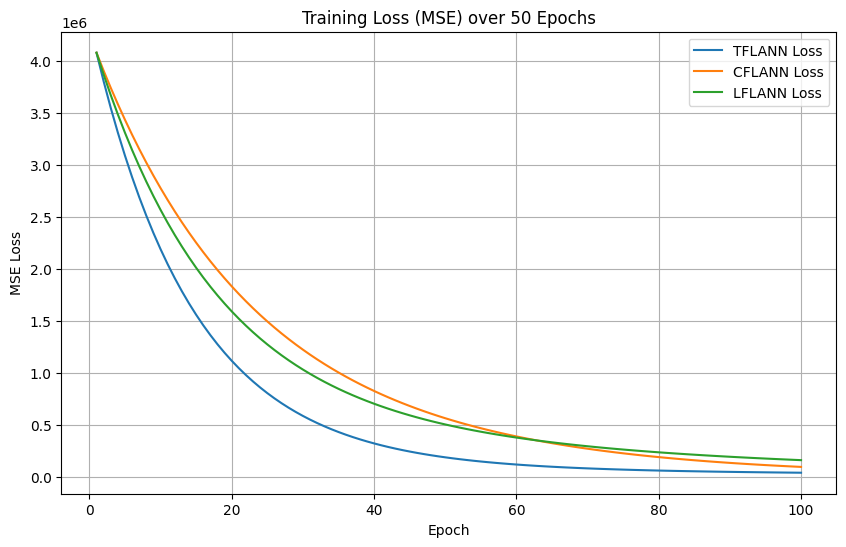

In [37]:
# Plot loss curves

plt.figure(figsize=(10, 6))
for name, losses in loss_histories.items():
    plt.plot(range(1, len(losses) + 1), losses, label=f'{name} Loss')

plt.title('Training Loss (MSE) over 50 Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


In [38]:
# Comparison table

import pandas as pd

rows = []
for name, res in results.items():
    rows.append({
        'Model': name,
        'Train MSE': res['train_mse'],
        'Train MAE': res['train_mae'],
        'Train R2': res['train_r2'],
        'Test MSE': res['test_mse'],
        'Test MAE': res['test_mae'],
        'Test R2': res['test_r2'],
    })

df_metrics = pd.DataFrame(rows)
# sort by Test MSE
print(df_metrics.sort_values('Test MSE').to_string(index=False))


 Model  Train MSE  Train MAE  Train R2     Test MSE    Test MAE       Test R2
LFLANN   0.114477   0.232687  0.937674 2.445441e+00    1.481702 -8.781762e+00
CFLANN   0.114477   0.232687  0.937674 2.445441e+00    1.481702 -8.781762e+00
TFLANN   0.114286   0.228571  0.937778 3.050842e+06 1507.974241 -1.220337e+07


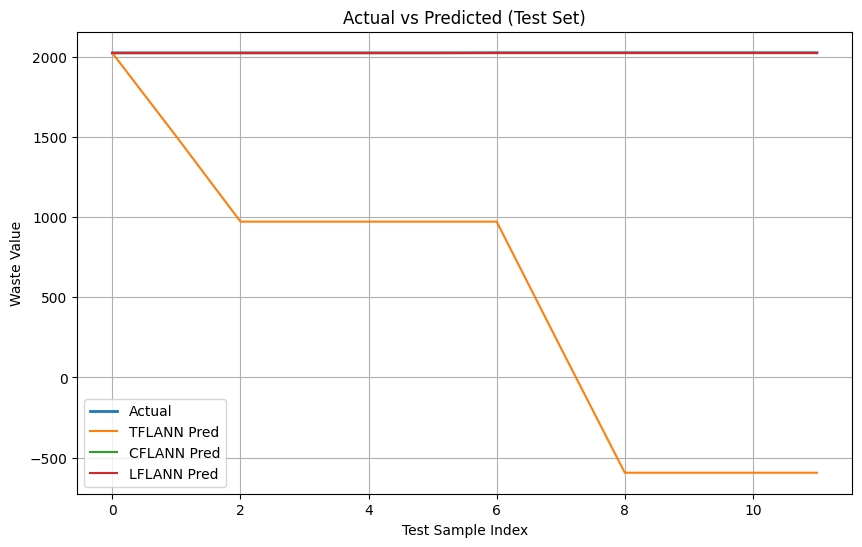

In [39]:
# Plot: Actual vs Predicted (test set)

plt.figure(figsize=(10, 6))
plt.plot(range(len(y_test)), y_test, label='Actual', linewidth=2)

for name, res in results.items():
    plt.plot(range(len(y_test)), res['y_pred_test'], label=f'{name} Pred')

plt.title('Actual vs Predicted (Test Set)')
plt.xlabel('Test Sample Index')
plt.ylabel('Waste Value')
plt.legend()
plt.grid(True)
plt.show()


## Notes

- Best model is the one with the lowest Test MSE / MAE and highest Test R2.
- Trigonometric basis can capture periodicity; Chebyshev and Legendre are orthogonal polynomial bases that can fit smooth trends.
- For this dataset (yearly with 2-month intervals), any seasonal periodicity may favor TFLANN, while smoother trends may favor CFLANN/LFLANN.
